In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
from tensorflow.keras.preprocessing import image_dataset_from_directory
import os
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import concurrent.futures

In [ ]:
#Importing Libraries

#tensorflow and tensorflow.keras.layers for building and training the GAN
# numpy  For numerical operations and to handle  arrays
# image_dataset_from_directory from tensorflow.keras.preprocessing it Helps to load the images from a directory
# os  to get the folder of the images path 
# PIL For image processing tasks
# matplotlib.pyplot to plot and visualize images and training results
# tqdm used to track the progress of each epoch
# time To measure time taken for training and other operations
# concurrent.futures to run operations in parallel to speed up tasks

In [3]:
IMG_SIZE = 64
BATCH_SIZE = 128
BUFFER_SIZE = 60000

# Load the dataset 
data_path = "C:/term 8/Deep learning/year work/img_align_celeba"

# Create the dataset
print("Loading dataset...")
dataset = image_dataset_from_directory(
    data_path,
    label_mode=None,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# Normalize the images to [-1, 1]
dataset = dataset.map(lambda x: (x - 127.5) / 127.5)

# Shuffle and prefetch
dataset = dataset.shuffle(BUFFER_SIZE).prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

print(f"Dataset ready with {len(dataset)} batches.")


Loading dataset...
Found 202599 files belonging to 1 classes.
Dataset ready with 1583 batches.


In [ ]:
#  Data Loading and Preprocessing
# This part handles loading, normalizing, shuffling, and prefetching the images to get them ready for training the GAN.

# IMG_SIZE = 64  Setting image size to 64x64 pixels
# BATCH_SIZE = 128  Using batches of 128 images
# BUFFER_SIZE = 60000 Buffer size for shuffling the dataset
# data_path = "C:/term 8/Deep learning/year work/img_align_celeba"
# dataset = image_dataset_from_directory(...) Load images, resize them to 64x64, and batch them
# dataset = dataset.map(lambda x: (x - 127.5) / 127.5) Normalize the images to [-1, 1] for the GAN
# dataset = dataset.shuffle(BUFFER_SIZE).prefetch(buffer_size=tf.data.experimental.AUTOTUNE)Shuffle and prefetch for performance

In [4]:
import tensorflow as tf
from tensorflow.keras import layers

def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Dense(8*8*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Reshape((8, 8, 256)))
    assert model.output_shape == (None, 8, 8, 256)  # Note: None is the batch size

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 16, 16, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 32, 32, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 64, 64, 3)

    return model

generator = make_generator_model()
generator.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16384)             1638400   
                                                                 
 batch_normalization (Batch  (None, 16384)             65536     
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 16384)             0         
                                                                 
 reshape (Reshape)           (None, 8, 8, 256)         0         
                                                                 
 conv2d_transpose (Conv2DTr  (None, 16, 16, 128)       819200    
 anspose)                                                        
                                                                 
 batch_normalization_1 (Bat  (None, 16, 16, 128)       5

In [ ]:
# Creating the Generator Model
#This cell defines and builds the generator part of the GAN
#The generator takes random noise as input and creates images. Here’s a breakdown of what this code does:

In [5]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[64, 64, 3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

discriminator = make_discriminator_model()
discriminator.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 64)        4864      
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 32, 32, 64)        0         
                                                                 
 dropout (Dropout)           (None, 32, 32, 64)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 128)       204928    
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 16, 16, 128)       0         
                                                                 
 dropout_1 (Dropout)         (None, 16, 16, 128)       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 8, 256)        

In [ ]:
#  Creating the Discriminator Model
#This section defines and builds the discriminator part of the GAN
#The discriminator  classify images as real or fake

In [6]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)


In [ ]:
# Loss Functions and Optimizers
#This section defines the loss functions and optimizers used for training the GAN

#cross_entropy  measures the difference between the predicted output and the actual output 
#discriminator_loss(real_output, fake_output) calculates the difference between the discriminator's predictions
#for real and fake images
#generator_loss(fake_output) which calculates the difference between the discriminator's predictions 
#for fake images and the ground truth (all ones).
#generator_optimizer and discriminator_optimizer Define Adam optimizers with a learning rate of 1e-4 for both the generator and discriminator models

Commencing epoch 1/16


  0%|          | 1/1583 [00:49<21:32:38, 49.03s/it]

Step 0/1583, Time per step: 49.01 sec, Remaining time: 1292.94 min


  3%|▎         | 51/1583 [01:46<27:02,  1.06s/it]  

Step 50/1583, Time per step: 2.08 sec, Remaining time: 53.18 min


...

Step 1500/1583, Time per step: 1.12 sec, Remaining time: 1.55 min


 98%|█████████▊| 1551/1583 [28:50<00:35,  1.11s/it]

Step 1550/1583, Time per step: 1.12 sec, Remaining time: 0.61 min


100%|██████████| 1583/1583 [29:25<00:00,  1.12s/it]



Time taken for epoch 1: 1765.48 sec



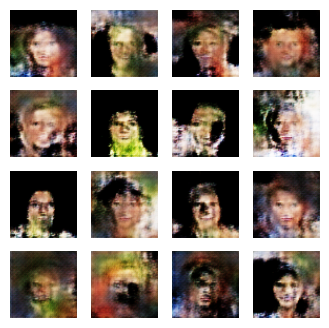

Commencing epoch 2/16


  0%|          | 1/1583 [00:46<20:25:50, 46.49s/it]

Step 0/1583, Time per step: 46.50 sec, Remaining time: 1226.83 min


  3%|▎         | 51/1583 [01:39<27:08,  1.06s/it]  

Step 50/1583, Time per step: 1.96 sec, Remaining time: 50.09 min


...

Step 1500/1583, Time per step: 1.12 sec, Remaining time: 1.55 min


 98%|█████████▊| 1551/1583 [28:55<00:34,  1.08s/it]

Step 1550/1583, Time per step: 1.12 sec, Remaining time: 0.62 min


100%|██████████| 1583/1583 [29:30<00:00,  1.12s/it]



Time taken for epoch 2: 1770.59 sec



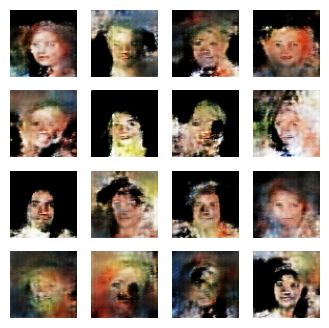

Commencing epoch 3/16


  0%|          | 1/1583 [00:47<20:41:32, 47.09s/it]

Step 0/1583, Time per step: 47.06 sec, Remaining time: 1241.49 min


  3%|▎         | 51/1583 [01:42<27:40,  1.08s/it]  

Step 50/1583, Time per step: 2.02 sec, Remaining time: 51.49 min


...

Step 1500/1583, Time per step: 1.10 sec, Remaining time: 1.53 min


 98%|█████████▊| 1551/1583 [28:30<00:33,  1.06s/it]

Step 1550/1583, Time per step: 1.10 sec, Remaining time: 0.61 min


100%|██████████| 1583/1583 [29:04<00:00,  1.10s/it]



Time taken for epoch 3: 1744.94 sec



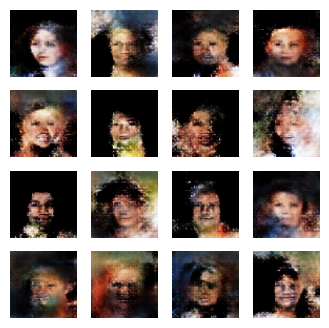

Commencing epoch 4/16


  0%|          | 1/1583 [00:46<20:23:52, 46.42s/it]

Step 0/1583, Time per step: 46.43 sec, Remaining time: 1225.07 min


  3%|▎         | 51/1583 [01:39<27:05,  1.06s/it]  

Step 50/1583, Time per step: 1.96 sec, Remaining time: 50.02 min


...

Step 1500/1583, Time per step: 1.10 sec, Remaining time: 1.53 min


 98%|█████████▊| 1551/1583 [28:28<00:34,  1.07s/it]

Step 1550/1583, Time per step: 1.10 sec, Remaining time: 0.61 min


100%|██████████| 1583/1583 [29:02<00:00,  1.10s/it]



Time taken for epoch 4: 1742.60 sec



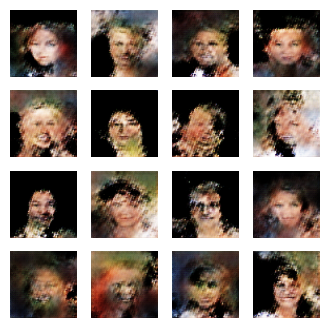

Commencing epoch 5/16


  0%|          | 1/1583 [00:45<20:11:52, 45.96s/it]

Step 0/1583, Time per step: 45.97 sec, Remaining time: 1212.73 min


  3%|▎         | 51/1583 [01:40<27:16,  1.07s/it]  

Step 50/1583, Time per step: 1.96 sec, Remaining time: 50.10 min


...

Step 1500/1583, Time per step: 1.10 sec, Remaining time: 1.52 min


 98%|█████████▊| 1551/1583 [28:21<00:33,  1.06s/it]

Step 1550/1583, Time per step: 1.10 sec, Remaining time: 0.60 min


100%|██████████| 1583/1583 [28:56<00:00,  1.10s/it]



Time taken for epoch 5: 1736.53 sec



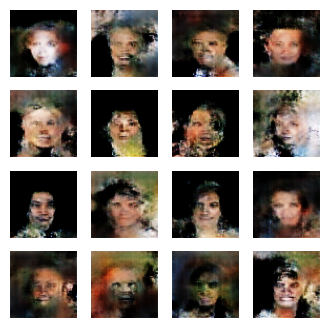

Commencing epoch 6/16


  0%|          | 1/1583 [00:46<20:13:04, 46.01s/it]

Step 0/1583, Time per step: 46.02 sec, Remaining time: 1214.21 min


  3%|▎         | 51/1583 [01:38<26:59,  1.06s/it]  

Step 50/1583, Time per step: 1.94 sec, Remaining time: 49.58 min


...

Step 1500/1583, Time per step: 1.09 sec, Remaining time: 1.51 min


 98%|█████████▊| 1551/1583 [28:16<00:34,  1.06s/it]

Step 1550/1583, Time per step: 1.09 sec, Remaining time: 0.60 min


100%|██████████| 1583/1583 [28:50<00:00,  1.09s/it]



Time taken for epoch 6: 1731.00 sec



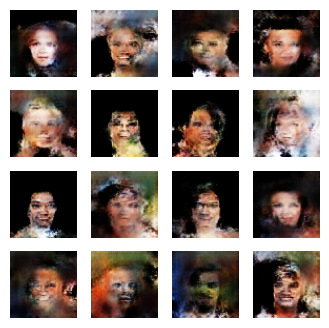

Commencing epoch 7/16


  0%|          | 1/1583 [00:44<19:40:09, 44.76s/it]

Step 0/1583, Time per step: 44.76 sec, Remaining time: 1180.95 min


  3%|▎         | 51/1583 [01:37<26:49,  1.05s/it]  

Step 50/1583, Time per step: 1.91 sec, Remaining time: 48.92 min


...

Step 1500/1583, Time per step: 1.09 sec, Remaining time: 1.51 min


 98%|█████████▊| 1551/1583 [28:17<00:34,  1.07s/it]

Step 1550/1583, Time per step: 1.09 sec, Remaining time: 0.60 min


100%|██████████| 1583/1583 [28:51<00:00,  1.09s/it]



Time taken for epoch 7: 1731.08 sec



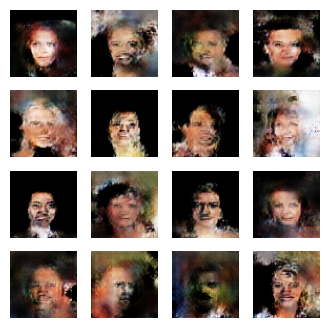

Commencing epoch 8/16


  0%|          | 1/1583 [00:45<19:47:33, 45.04s/it]

Step 0/1583, Time per step: 45.04 sec, Remaining time: 1188.33 min


  3%|▎         | 51/1583 [01:38<27:06,  1.06s/it]  

Step 50/1583, Time per step: 1.92 sec, Remaining time: 49.12 min


...

Step 1500/1583, Time per step: 1.10 sec, Remaining time: 1.53 min


 98%|█████████▊| 1551/1583 [28:31<00:34,  1.07s/it]

Step 1550/1583, Time per step: 1.10 sec, Remaining time: 0.61 min


100%|██████████| 1583/1583 [29:05<00:00,  1.10s/it]



Time taken for epoch 8: 1745.66 sec



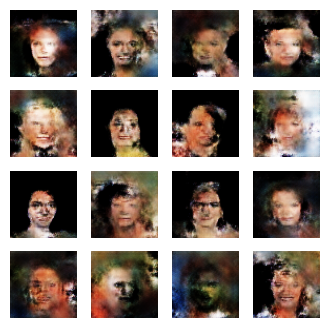

Commencing epoch 9/16


  0%|          | 1/1583 [00:46<20:20:12, 46.28s/it]

Step 0/1583, Time per step: 46.26 sec, Remaining time: 1220.61 min


  3%|▎         | 51/1583 [01:39<27:01,  1.06s/it]  

Step 50/1583, Time per step: 1.95 sec, Remaining time: 49.86 min


...

Step 1500/1583, Time per step: 1.10 sec, Remaining time: 1.52 min


 98%|█████████▊| 1551/1583 [28:24<00:34,  1.07s/it]

Step 1550/1583, Time per step: 1.10 sec, Remaining time: 0.60 min


100%|██████████| 1583/1583 [28:58<00:00,  1.10s/it]



Time taken for epoch 9: 1738.62 sec



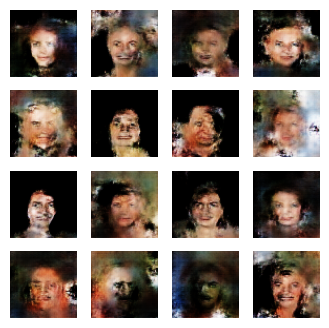

Commencing epoch 10/16


  0%|          | 1/1583 [00:45<19:59:43, 45.50s/it]

Step 0/1583, Time per step: 45.52 sec, Remaining time: 1200.85 min


  3%|▎         | 51/1583 [01:38<27:09,  1.06s/it]  

Step 50/1583, Time per step: 1.94 sec, Remaining time: 49.50 min


...

Step 1500/1583, Time per step: 1.10 sec, Remaining time: 1.53 min


 98%|█████████▊| 1551/1583 [28:30<00:35,  1.10s/it]

Step 1550/1583, Time per step: 1.10 sec, Remaining time: 0.61 min


100%|██████████| 1583/1583 [29:06<00:00,  1.10s/it]



Time taken for epoch 10: 1746.15 sec



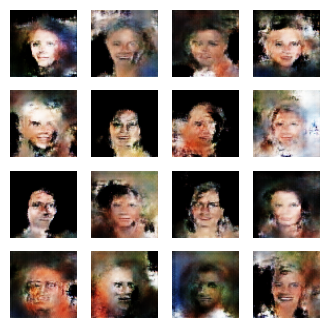

Commencing epoch 11/16


  0%|          | 1/1583 [00:47<21:00:46, 47.82s/it]

Step 0/1583, Time per step: 47.82 sec, Remaining time: 1261.68 min


  3%|▎         | 51/1583 [01:41<27:12,  1.07s/it]  

Step 50/1583, Time per step: 1.99 sec, Remaining time: 50.92 min


...

Step 1500/1583, Time per step: 1.11 sec, Remaining time: 1.54 min


 98%|█████████▊| 1551/1583 [28:43<00:34,  1.07s/it]

Step 1550/1583, Time per step: 1.11 sec, Remaining time: 0.61 min


100%|██████████| 1583/1583 [29:17<00:00,  1.11s/it]



Time taken for epoch 11: 1757.66 sec



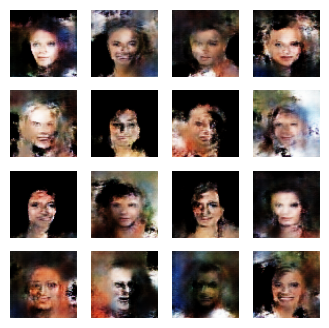

Commencing epoch 12/16


  0%|          | 1/1583 [00:46<20:13:42, 46.03s/it]

Step 0/1583, Time per step: 46.04 sec, Remaining time: 1214.63 min


  3%|▎         | 51/1583 [01:39<27:18,  1.07s/it]  

Step 50/1583, Time per step: 1.95 sec, Remaining time: 49.78 min


...

Step 1500/1583, Time per step: 1.11 sec, Remaining time: 1.53 min


 98%|█████████▊| 1551/1583 [28:38<00:34,  1.09s/it]

Step 1550/1583, Time per step: 1.11 sec, Remaining time: 0.61 min


100%|██████████| 1583/1583 [29:14<00:00,  1.11s/it]



Time taken for epoch 12: 1755.01 sec



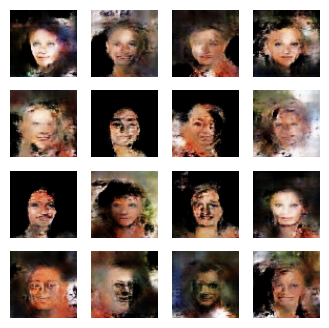

Commencing epoch 13/16


  0%|          | 1/1583 [00:58<25:48:31, 58.73s/it]

Step 0/1583, Time per step: 58.70 sec, Remaining time: 1548.59 min


  3%|▎         | 51/1583 [01:55<27:46,  1.09s/it]  

Step 50/1583, Time per step: 2.27 sec, Remaining time: 57.93 min


...

Step 1500/1583, Time per step: 1.12 sec, Remaining time: 1.56 min


 98%|█████████▊| 1551/1583 [29:02<00:34,  1.08s/it]

Step 1550/1583, Time per step: 1.12 sec, Remaining time: 0.62 min


100%|██████████| 1583/1583 [29:36<00:00,  1.12s/it]



Time taken for epoch 13: 1776.84 sec



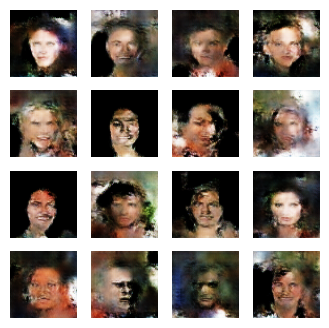

Commencing epoch 14/16


  0%|          | 1/1583 [00:47<20:59:32, 47.77s/it]

Step 0/1583, Time per step: 47.75 sec, Remaining time: 1259.81 min


  3%|▎         | 51/1583 [01:41<27:42,  1.09s/it]  

Step 50/1583, Time per step: 2.00 sec, Remaining time: 51.10 min


...

Step 1500/1583, Time per step: 1.11 sec, Remaining time: 1.54 min


 98%|█████████▊| 1551/1583 [28:44<00:34,  1.09s/it]

Step 1550/1583, Time per step: 1.11 sec, Remaining time: 0.61 min


100%|██████████| 1583/1583 [29:19<00:00,  1.11s/it]



Time taken for epoch 14: 1759.34 sec



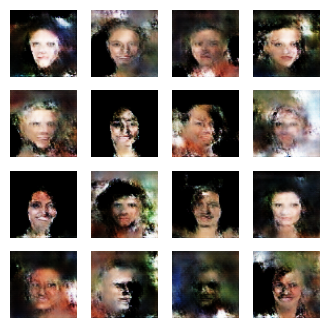

Commencing epoch 15/16


  0%|          | 1/1583 [00:57<25:24:02, 57.80s/it]

Step 0/1583, Time per step: 57.79 sec, Remaining time: 1524.79 min


  3%|▎         | 51/1583 [01:54<30:07,  1.18s/it]  

Step 50/1583, Time per step: 2.24 sec, Remaining time: 57.23 min


...

Step 1500/1583, Time per step: 1.12 sec, Remaining time: 1.56 min


 98%|█████████▊| 1551/1583 [29:02<00:34,  1.08s/it]

Step 1550/1583, Time per step: 1.12 sec, Remaining time: 0.62 min


100%|██████████| 1583/1583 [29:36<00:00,  1.12s/it]



Time taken for epoch 15: 1776.84 sec



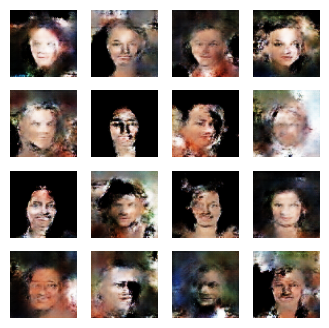

Commencing epoch 16/16


  0%|          | 1/1583 [00:47<20:44:48, 47.21s/it]

Step 0/1583, Time per step: 47.22 sec, Remaining time: 1245.82 min


  3%|▎         | 51/1583 [01:40<27:57,  1.09s/it]  

Step 50/1583, Time per step: 1.97 sec, Remaining time: 50.44 min


...

Step 1500/1583, Time per step: 1.11 sec, Remaining time: 1.54 min


 98%|█████████▊| 1551/1583 [28:43<00:35,  1.11s/it]

Step 1550/1583, Time per step: 1.11 sec, Remaining time: 0.61 min


100%|██████████| 1583/1583 [29:17<00:00,  1.11s/it]



Time taken for epoch 16: 1757.68 sec



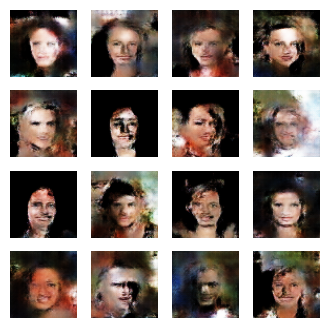

In [16]:
NUM_EPOCHS = 16
NOISE_DIM = 100
NUM_EXAMPLES = 16

#the Seed forthe generating images
seed = tf.random.normal([NUM_EXAMPLES, NOISE_DIM])

# Define train step function
@tf.function
def train_step(images, BATCH_SIZE, NOISE_DIM):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])
    
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)
        
        generator_loss_val = generator_loss(fake_output)
        discriminator_loss_val = discriminator_loss(real_output, fake_output)
    
    gen_gradients = gen_tape.gradient(generator_loss_val, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(discriminator_loss_val, discriminator.trainable_variables)
    
    generator_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))
    
    return generator_loss_val, discriminator_loss_val

# Define training function
def train(dataset, epochs, BATCH_SIZE, NOISE_DIM):
    gen_losses = []
    disc_losses = []
    
    for epoch in range(epochs):
        start_time = time.time()
        print(f'Commencing epoch {epoch + 1}/{epochs}')
        
        for step, image_batch in tqdm(enumerate(dataset), total=len(dataset)):
            gen_loss, disc_loss = train_step(image_batch, BATCH_SIZE, NOISE_DIM)
            
            if step % 50 == 0:
                time_per_step = (time.time() - start_time) / (step + 1)
                remaining_steps = len(dataset) - step
                remaining_time = remaining_steps * time_per_step
                print(f'Step {step}/{len(dataset)}, Time per step: {time_per_step:.2f} sec, Remaining time: {remaining_time/60:.2f} min')
                print(f'Generator Loss: {gen_loss.numpy():.4f}, Discriminator Loss: {disc_loss.numpy():.4f}', end='\r')
        
        gen_losses.append(gen_loss)
        disc_losses.append(disc_loss)
        
        print(f'\nTime taken for epoch {epoch + 1}: {time.time() - start_time:.2f} sec\n')
        
        generate_and_save_images(generator, epoch + 1, seed)
    
    return gen_losses, disc_losses

# Define function to generate and save images
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    
    fig = plt.figure(figsize=(4, 4))
    
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow((predictions[i] * 127.5 + 127.5).numpy().astype(np.uint8))
        plt.axis('off')
    
    plt.savefig(f'generated_image_epoch_{epoch:04d}.png')
    plt.show()

# Train the model
BATCH_SIZE = 64 
generator_losses, discriminator_losses = train(dataset, NUM_EPOCHS, BATCH_SIZE, NOISE_DIM)


In [ ]:
#This section is responsible for training the GAN model

#Sets the parameters such -the number of epochs, noise dimension, number of examples to generate
#Defines a seed using random noise to generate consistent images for visualization during training
#Implements the train_step function toperform a single optimization step on the generator and discriminator models
#Defines the train function, which iterates over the dataset for the specified number of epochs, updating the generator and discriminator models using the `train_step` function
#Prints progress during training, inclyuding epoch number
#,step number, time per step, remaining time, generator loss, and discriminator loss
#After each epoch, saves and displays generated images for visualization

C:\Users\ABDALLA\anaconda3\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


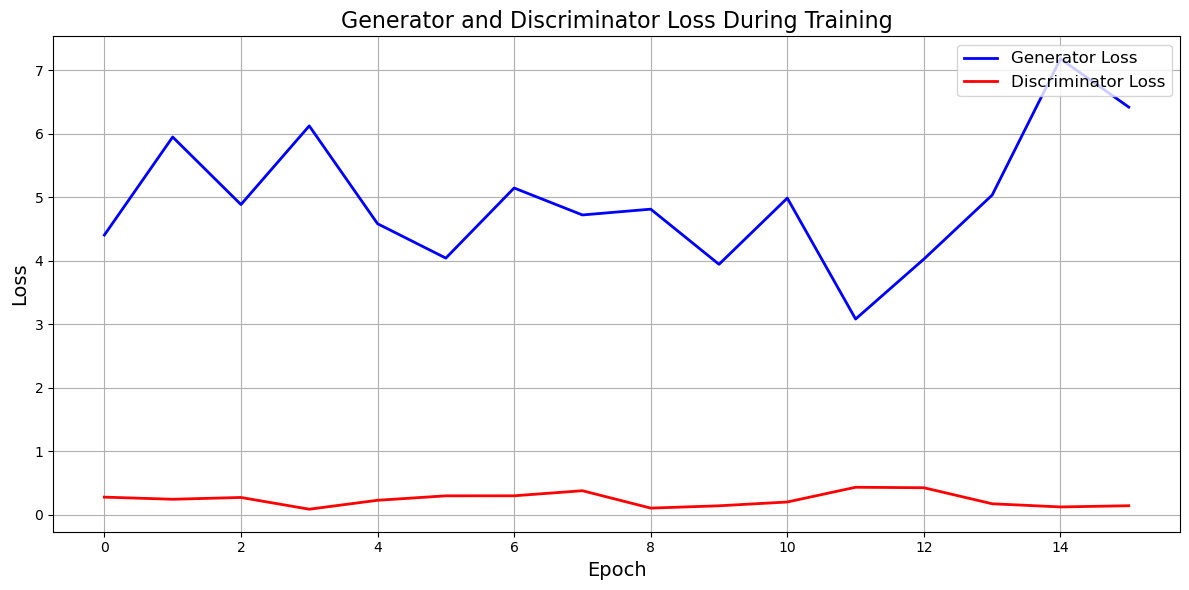

In [17]:
#Save the Model and Plot Loss History
# Save the generator model
generator.save('generator_model.h5')

# Save the discriminator model
discriminator.save('discriminator_model.h5')

# Plot the loss history 
plt.figure(figsize=(12, 6))
plt.plot(generator_losses, label='Generator Loss', color='blue', linewidth=2)
plt.plot(discriminator_losses, label='Discriminator Loss', color='red', linewidth=2)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Generator and Discriminator Loss During Training', fontsize=16)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Model Saving and Loss Plotting
#This cell saves the trained generator and discriminator models  and plots the loss historyy during training

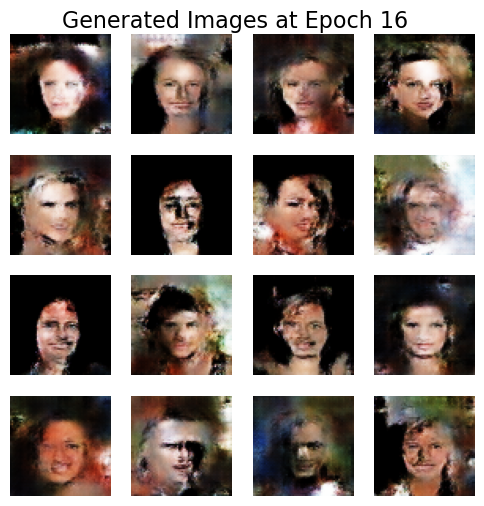

In [19]:
#Generate and Display Final Images
def evaluate_model(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(6, 6))  

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow((predictions[i] * 127.5 + 127.5).numpy().astype(np.uint8))
        plt.axis('off')

    plt.subplots_adjust(wspace=0.2, hspace=0.2)
    plt.suptitle(f"Generated Images at Epoch {epoch}", fontsize=16, y=0.92)  
    plt.show()

# Generate and display final images
evaluate_model(generator, NUM_EPOCHS, seed)


In [ ]:
#  Generating and Displaying Final Images
#This section defines a function evaluate_model to generatee and display final images 
#generated by the generator model after training
